# 12 — Comment Extraction Training Data

Extracts every `(* ... *)` comment from `.aro` files in `Examples/` and
`../ARO-Application/` and pairs each comment with the code it documents.

Two complementary directions are generated for each comment:

| Direction | Instruction template | Target |
|-----------|---------------------|--------|
| code → comment | `Explain / Describe / What does / Summarise <code>` | comment text |
| comment → code | model-reworded comment as imperative instruction | code |

The local model generates **4 paraphrase variations** of every instruction.
Each raw comment-code pair produces **13 training samples**:
4 (code→comment templates) + 4 (code→comment paraphrases) + 1 (comment→code base) + 4 (comment→code paraphrases).

**Inputs:**
- `/Users/kris/Projects/ARO-App/Examples/` — bundled examples (100 `.aro` files)
- `/Users/kris/Projects/ARO-Application/`  — real-world apps (23 `.aro` files)

**Output:** `comment_pairs.jsonl` — 6,903 samples
            Appended to `../data/02_knowledge/knowledge_pairs.jsonl`

**Results (last run):**

| Source | Files | Raw pairs | Training samples |
|--------|------:|----------:|-----------------:|
| Examples/ | 100 | 430 | 5,590 |
| ARO-Application/ | 23 | 101 | 1,313 |
| **Total** | **123** | **531** | **6,903** |

**Pair type breakdown:**

| Type | Samples |
|------|--------:|
| code→comment (template) | 2,124 |
| code→comment (paraphrase) | 2,124 |
| comment→code (base) | 531 |
| comment→code (paraphrase) | 2,124 |
| **Total** | **6,903** |

## Setup

In [ ]:
import sys, importlib, json, re, random
from pathlib import Path

_cfg_dir = Path('.').resolve()
if str(_cfg_dir) not in sys.path:
    sys.path.insert(0, str(_cfg_dir))
import config; importlib.reload(config); from config import *

ARO_APPLICATION_ROOT = Path('/Users/kris/Projects/ARO-Application')
OUT_FILE = SCRIPT_DIR / 'comment_pairs.jsonl'

SYSTEM = """You are an expert ARO language programmer.
ARO (Action Result Object) is a DSL for expressing business logic as natural-language statements.

SYNTAX:
  (FeatureSetName: BusinessActivity) {
      Verb [the] <result[:qualifier]> preposition [the] <object[:qualifier]>.
  }

KEY RULES:
- Articles (a/an/the) are optional everywhere
- String concatenation: ++ (NOT +)
- Variable names: hyphenated lowercase e.g. <user-id>, <order-total>
- Forbidden variable name prefixes: is-, with-, empty-
- Variables are IMMUTABLE — bind once; use a new name for each transformation
- Exactly ONE Application-Start per application (error if 0 or multiple)
- openapi.yaml REQUIRED for HTTP server; operationId must match feature set name
- Long-running apps: Keepalive the <application> for the <events>.

HTTP:
- Path params:   Extract the <id> from the <pathParameters: id>.
- Request body:  Extract the <data> from the <request: body>.
- Return statuses: <OK: status>, <Created: status>, <NoContent: status>,
                   <NotFound: status>, <BadRequest: status>, <Conflict: status>,
                   <Unauthorized: status>, <InternalServerError: status>

CONTROL FLOW:
- Conditional:   when <condition> { statements }
- Loop:          For each <item> in <list> { statements }
- Match:         match <var> { case value { statements } case other { statements } }
- Guard on declaration: (Name: EventName Handler) when <field> = value { ... }

COMPUTE & ARITHMETIC:
- Compute the <total> from <price> * <qty>.
- Compute the <upper: uppercase> from <text>.
- Compute the <len: length> from <text>.
- Supported ops: +, -, *, /, % (integers); ++ (strings)

AVAILABLE ACTIONS (verb → role → prepositions):
- Extract     REQUEST   from/with     — pull data from request/event/object
- Retrieve    REQUEST   from/where    — fetch from repository or service
- Compute     OWN       from/with/for — arithmetic, string ops, built-in transforms
- Transform   OWN       from/with     — type coercion (e.g. string → int)
- Validate    OWN       for/with      — check constraints, return bool
- Create      OWN       with          — instantiate struct or entity
- Filter      OWN       where/with    — select subset of collection
- Return      RESPONSE  with/for      — send HTTP response and end feature set
- Store       EXPORT    into          — persist to repository (auto-generates id)
- Log         EXPORT    to            — write to console or log service
- Emit        EXPORT    with          — publish domain event to EventBus
- Publish     EXPORT    as            — share variable across feature sets

Always wrap ARO code in ```aro ... ``` fences.
Always generate complete, valid ARO that would pass `aro check`.
"""

print('Setup complete.')
print(f'  Examples root        : {EXAMPLES_DIR}')
print(f'  ARO-Application root : {ARO_APPLICATION_ROOT}')
print(f'  Output file          : {OUT_FILE}')

## Load model

In [2]:
model, tokenizer, _load_fn, mlx_generate, make_sampler = load_model(with_adapter=False)
print('Model ready.')

/Library/Python/3.9/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/kris/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit (base weights)...


Fetching 15 files: 100%|██████████| 15/15 [00:00<00:00, 204933.42it/s]


Model ready.
Model ready.


## Chat helper

In [3]:
def chat(messages: list[dict], max_tokens: int = 200, temperature: float = 0.7) -> str:
    sampler = make_sampler(temp=temperature)
    prompt  = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    return mlx_generate(
        model, tokenizer, prompt=prompt,
        max_tokens=max_tokens, sampler=sampler, verbose=False,
    ).strip()

## Comment extraction

In [4]:
# Matches (* ... *) — single-line and multi-line
_COMMENT_RE = re.compile(r'\(\*(.*?)\*\)', re.DOTALL)

MIN_CODE_LINES = 1
MAX_CODE_LINES = 8


def _clean_comment(raw: str) -> str:
    lines = []
    for ln in raw.splitlines():
        ln = ln.strip().lstrip('*').strip()
        if ln:
            lines.append(ln)
    return ' '.join(lines).strip()


def _is_file_header(text: str, comment_idx: int) -> bool:
    """Skip the very first comment when it looks like a file-level header."""
    return comment_idx == 0 and len(text) > 200


def extract_comment_code_pairs(path: Path) -> list[dict]:
    """
    Return [{comment, code, source}] for every inline comment
    followed by at least MIN_CODE_LINES of ARO code.
    """
    try:
        src = path.read_text(encoding='utf-8', errors='ignore')
    except Exception:
        return []

    pairs = []
    comment_idx = 0

    for m in _COMMENT_RE.finditer(src):
        raw_comment  = m.group(1)
        comment_text = _clean_comment(raw_comment)

        if not comment_text or len(comment_text) < 15:
            continue
        if _is_file_header(comment_text, comment_idx):
            comment_idx += 1
            continue
        comment_idx += 1

        after      = src[m.end():]
        code_lines = []
        for ln in after.splitlines():
            stripped = ln.strip()
            if not stripped:
                continue
            if stripped.startswith('(*'):
                break
            if stripped.startswith('(') and ':' in stripped and stripped.endswith('{'):
                break
            if stripped == '}':
                break
            code_lines.append(stripped)
            if len(code_lines) >= MAX_CODE_LINES:
                break

        if len(code_lines) < MIN_CODE_LINES:
            continue

        pairs.append({
            'comment': comment_text,
            'code':    '\n'.join(code_lines),
            'source':  str(path),
        })

    return pairs


def mine_all_files() -> list[dict]:
    all_pairs = []
    for label, root in [('Examples', EXAMPLES_DIR), ('ARO-Application', ARO_APPLICATION_ROOT)]:
        files       = sorted(root.rglob('*.aro'))
        cnt_files   = 0
        cnt_pairs   = 0
        for f in files:
            fp = extract_comment_code_pairs(f)
            if fp:
                cnt_files += 1
                cnt_pairs += len(fp)
                all_pairs.extend(fp)
        print(f'  {label:<20}  {cnt_files:>3} files with comments  ->  {cnt_pairs:>4} raw pairs')
    print(f'\nTotal raw comment-code pairs: {len(all_pairs)}')
    return all_pairs


raw_pairs = mine_all_files()

  Examples              100 files with comments  ->   430 raw pairs
  ARO-Application        23 files with comments  ->   101 raw pairs

Total raw comment-code pairs: 531


## Inspect raw pairs

In [5]:
sample = random.sample(raw_pairs, min(5, len(raw_pairs)))
for p in sample:
    print(f"SOURCE : {Path(p.get('source', '')).name}")
    print(f"COMMENT: {p['comment'][:120]}")
    print('CODE   :')
    print(p['code'])
    print()

SOURCE : main.aro
COMMENT: Test 4: Filter with numeric comparison
CODE   :
Log "=== Test 4: Numeric Filter ===" to the <console>.
Filter the <high-value: List> from the <orders>
where <amount> > 200.
Log "High Value Orders (amount > 200):" to the <console>.
Log <high-value> to the <console>.
Reduce the <high-value-total: Float> from the <high-value>
with sum(<amount>).
Log "High Value Total:" to the <console>.

SOURCE : processor.aro
COMMENT: Double threshold, capped at 1024. Capture below-cap before the Update so both guards use the same pre-mutation value of 
CODE   :
Compute the <below-cap> from (<state: threshold>) < 1024.
Compute the <new-threshold> from (<state: threshold>) * 2.
Update the <state: threshold> with <new-threshold> when <below-cap>.
Store the <state> into the <scan-state-repository> when <below-cap>.
Emit a <PruneStats: event> with "prune".
Return an <OK: status> for the <processing>.

SOURCE : main.aro
COMMENT: Nested constant expressions
CODE   :
Compute the <resu

## Instruction paraphrase helpers

**Code -> Comment**: 4 fixed templates (Explain / Describe / What does / Summarise)
plus 4 model paraphrases of the Explain form.

**Comment -> Code**: model first rewrites the comment as an imperative instruction,
then generates 4 paraphrase variants of that instruction.

In [ ]:
_PARA_SYSTEM = """You are a dataset augmentation assistant for ARO (Action Result Object), a programming language.
Given an instruction about ARO code, rewrite it in a different but semantically equivalent way.
Preserve the exact technical meaning — do not change what action is being asked for.
Return ONLY the rewritten instruction — no explanation, no quotes, no preamble."""

_CODE2COMMENT_TEMPLATES = [
    "Explain what this ARO code does:\n\n```aro\n{code}\n```",
    "Describe the purpose of the following ARO code:\n\n```aro\n{code}\n```",
    "What does this ARO snippet do?\n\n```aro\n{code}\n```",
    "Summarise this ARO code in plain language:\n\n```aro\n{code}\n```",
]

# ── Paraphrase configuration ────────────────────────────────────────────────
N_CODE2COMMENT_PARA = 1    # paraphrase variants per code->comment base (was 4)
N_COMMENT2CODE_PARA = 0    # paraphrase variants per comment->code instruction (was 4)
PARA_TEMP           = 0.15 # temperature for paraphrase generation (was 0.85)


def _code2comment_fixed(code: str) -> list[str]:
    """4 fixed template instructions for code -> comment."""
    return [t.format(code=code) for t in _CODE2COMMENT_TEMPLATES]


def _paraphrase(instruction: str, n: int = 4, temperature: float = PARA_TEMP) -> list[str]:
    """Return n paraphrase variations of instruction."""
    results = []
    for _ in range(n):
        out = chat([
            {'role': 'system', 'content': _PARA_SYSTEM},
            {'role': 'user',   'content':
                f'Rewrite this instruction as a different imperative sentence '
                f'describing the same ARO code. Instruction: {instruction}'},
        ], max_tokens=120, temperature=temperature).strip().strip('"').strip("'")
        if out and out not in results:
            results.append(out)
    while len(results) < n:
        results.append(instruction)
    return results[:n]


def _comment_to_instruction(comment: str) -> str:
    """Reword a comment into an imperative code-generation instruction."""
    return chat([
        {'role': 'system', 'content':
            "You are a technical writing assistant. "
            "Turn the following ARO code comment into a concise imperative instruction "
            "(1-2 sentences) that tells a developer what ARO code to write. "
            "Start with a verb. Return ONLY the instruction."},
        {'role': 'user', 'content': comment},
    ], max_tokens=100, temperature=0.6)


def _is_consistent(comment, instruction, threshold=0.25):
    """Check semantic consistency between comment and generated instruction."""
    c_words = {w.lower() for w in comment.split() if len(w) > 4}
    if not c_words:
        return True
    i_words = {w.lower() for w in instruction.split()}
    return len(c_words & i_words) / len(c_words) >= threshold


print('Helpers ready.')
print(f'  N_CODE2COMMENT_PARA : {N_CODE2COMMENT_PARA}')
print(f'  N_COMMENT2CODE_PARA : {N_COMMENT2CODE_PARA}')
print(f'  PARA_TEMP           : {PARA_TEMP}')

## Build training pairs

Per raw comment-code pair:

- **4** code->comment fixed templates
- **4** code->comment model paraphrases
- **1** comment->code base instruction  
- **4** comment->code paraphrase variants

= **13 training samples** per raw pair.

In [ ]:
# Resume support
done_keys: set[str] = set()
all_pairs: list[dict] = []

if OUT_FILE.exists():
    for line in OUT_FILE.read_text().splitlines():
        if line.strip():
            try:
                p = json.loads(line)
                done_keys.add(p.get('source_key', ''))
                all_pairs.append(p)
            except Exception:
                pass
    print(f'Resumed: {len(all_pairs)} pairs, {len(done_keys)} source keys done.')
else:
    print('Starting fresh.')


total = len(raw_pairs)
for i, rp in enumerate(raw_pairs):
    skey = f"{rp.get('source', '')}::{i}"
    if skey in done_keys:
        continue

    comment  = rp['comment']
    aro_code = rp['code']
    source   = rp.get('source', '')

    def _pair(instr, reply, itype):
        return {
            'messages': [
                {'role': 'system',    'content': SYSTEM},
                {'role': 'user',      'content': instr},
                {'role': 'assistant', 'content': reply},
            ],
            'task_type':        'code_explanation' if itype.startswith('code2comment') else 'code_generation',
            'instruction_type': itype,
            'source_key':       skey,
            'source':           source,
        }

    # A. Code -> Comment: 4 fixed templates
    for instr in _code2comment_fixed(aro_code):
        all_pairs.append(_pair(instr, comment, 'code2comment_template'))

    # B. Code -> Comment: N_CODE2COMMENT_PARA model paraphrases
    if N_CODE2COMMENT_PARA > 0:
        base_explain = f'Explain what this ARO code does:\n\n```aro\n{aro_code}\n```'
        for variant in _paraphrase(base_explain, n=N_CODE2COMMENT_PARA, temperature=PARA_TEMP):
            all_pairs.append(_pair(variant, comment, 'code2comment_paraphrase'))

    # C. Comment -> Code: base instruction with consistency check + paraphrases
    base_c2code = _comment_to_instruction(comment)
    if not _is_consistent(comment, base_c2code):
        # Retry once at temp=0 for more faithful output
        base_c2code_retry = chat([
            {'role': 'system', 'content':
                "You are a technical writing assistant. "
                "Turn the following ARO code comment into a concise imperative instruction "
                "(1-2 sentences) that tells a developer what ARO code to write. "
                "Start with a verb. Return ONLY the instruction."},
            {'role': 'user', 'content': comment},
        ], max_tokens=100, temperature=0.0)
        if _is_consistent(comment, base_c2code_retry):
            base_c2code = base_c2code_retry
        else:
            # Skip this pair — instruction is semantically inconsistent with comment
            done_keys.add(skey)
            continue

    all_pairs.append(_pair(base_c2code, f'```aro\n{aro_code}\n```', 'comment2code_base'))
    if N_COMMENT2CODE_PARA > 0:
        for variant in _paraphrase(base_c2code, n=N_COMMENT2CODE_PARA, temperature=PARA_TEMP):
            all_pairs.append(_pair(variant, f'```aro\n{aro_code}\n```', 'comment2code_paraphrase'))

    done_keys.add(skey)

    # Incremental save every 10 source pairs
    if (i + 1) % 10 == 0 or i == total - 1:
        with OUT_FILE.open('w') as f:
            for p in all_pairs:
                f.write(json.dumps(p) + '\n')
        print(f'  [{i+1}/{total}] {len(all_pairs)} pairs saved', flush=True)

print(f'\nDone. {len(all_pairs)} total training pairs -> {OUT_FILE}')


def _show_sample(pairs, n=2, label=''):
    import random as _r
    sample_pool = _r.sample(pairs, min(n, len(pairs)))
    print(f'\n── Sample ({label}, {len(pairs)} total) ──────────────────────')
    for i, s in enumerate(sample_pool, 1):
        if 'messages' in s:
            user = s['messages'][1]['content'] if len(s['messages']) > 1 else ''
            asst = s['messages'][2]['content'] if len(s['messages']) > 2 else ''
        else:
            user = s.get('instruction', s.get('user', ''))
            asst = s.get('output', s.get('assistant', ''))
        task = s.get('task_type', s.get('source', '?'))
        print(f'  [{i}] task={task}')
        print(f'       USER: {user[:120].strip()!r}')
        print(f'       ASST: {asst[:120].strip()!r}')
    print('─' * 60)

_show_sample(all_pairs, label='NB12 comment_extraction')

## Inspect output

In [8]:
from collections import Counter

_saved: list[dict] = []
for line in OUT_FILE.read_text().splitlines():
    if line.strip():
        try: _saved.append(json.loads(line))
        except Exception: pass

by_type = Counter(p['instruction_type'] for p in _saved)
print(f'Total pairs: {len(_saved)}')
for k, v in sorted(by_type.items()):
    print(f'  {k:<35} {v:>5}')

print()
for p in random.sample(_saved, min(3, len(_saved))):
    print(f"TYPE : {p['instruction_type']}")
    print(f"USER : {p['messages'][1]['content'][:140]}")
    print(f"ASST : {p['messages'][2]['content'][:140]}")
    print()

Total pairs: 6903
  code2comment_paraphrase              2124
  code2comment_template                2124
  comment2code_base                     531
  comment2code_paraphrase              2124

TYPE : code2comment_template
USER : Explain what this ARO code does:

```aro
Log "=== Test 1: Simple Array Reduce ===" to the <console>.
Create the <numbers> with [1, 2, 3, 4, 
ASST : Test 1: Simple array with Reduce operations

TYPE : code2comment_paraphrase
USER : Show the user what this ARO code does by displaying the output in the console.
ASST : Create the directory in current location

TYPE : code2comment_template
USER : Summarise this ARO code in plain language:

```aro
Log <message> to the <console>.
```
ASST : ── Sink syntax: variable reference without "the" ────────────────



## Append to knowledge_pairs.jsonl

In [9]:
PAIRS_FILE.parent.mkdir(parents=True, exist_ok=True)

existing = len([l for l in PAIRS_FILE.read_text().splitlines() if l.strip()]) if PAIRS_FILE.exists() else 0
new_lines = [l for l in OUT_FILE.read_text().splitlines() if l.strip()]

with PAIRS_FILE.open('a') as out:
    for line in new_lines:
        out.write(line + '\n')

print(f'Appended {len(new_lines)} pairs to {PAIRS_FILE}')
print(f'  Before: {existing}  After: {existing + len(new_lines)}')

Appended 6903 pairs to /Volumes/Models/data/../data/02_knowledge/knowledge_pairs.jsonl
  Before: 13247  After: 20150


## Summary

In [10]:
print('=' * 60)
print('Comment Extraction Training Data — Summary')
print('=' * 60)

_all: list[dict] = []
for line in OUT_FILE.read_text().splitlines():
    if line.strip():
        try: _all.append(json.loads(line))
        except Exception: pass

c2c    = [p for p in _all if p['task_type'] == 'code_explanation']
c2code = [p for p in _all if p['task_type'] == 'code_generation']

print(f'\nRaw comment-code pairs mined : {len(done_keys)}')
print(f'\nCode -> Comment pairs        : {len(c2c)}')
print(f'  template    : {sum(1 for p in c2c    if p["instruction_type"] == "code2comment_template")}')
print(f'  paraphrase  : {sum(1 for p in c2c    if p["instruction_type"] == "code2comment_paraphrase")}')
print(f'\nComment -> Code pairs        : {len(c2code)}')
print(f'  base        : {sum(1 for p in c2code if p["instruction_type"] == "comment2code_base")}')
print(f'  paraphrase  : {sum(1 for p in c2code if p["instruction_type"] == "comment2code_paraphrase")}')
print(f'\nTotal                        : {len(_all)}')
print(f'Output file                  : {OUT_FILE}')

Comment Extraction Training Data — Summary

Raw comment-code pairs mined : 531

Code -> Comment pairs        : 4248
  template    : 2124
  paraphrase  : 2124

Comment -> Code pairs        : 2655
  base        : 531
  paraphrase  : 2124

Total                        : 6903
Output file                  : /Users/kris/Projects/ARO-App/Train/script/comment_pairs.jsonl


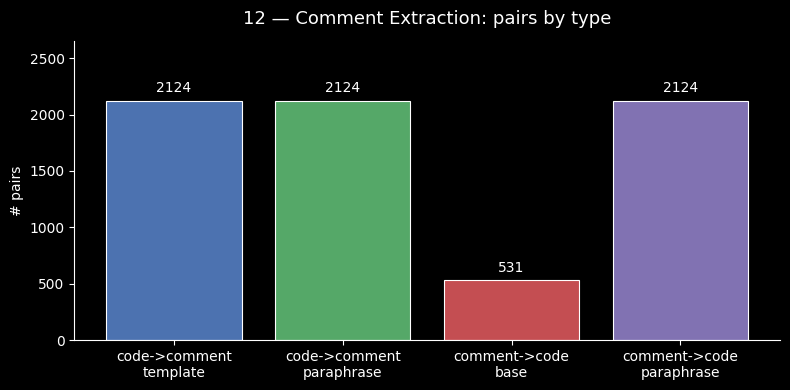

In [11]:
import matplotlib.pyplot as plt

labels = ['code->comment\ntemplate', 'code->comment\nparaphrase',
          'comment->code\nbase',     'comment->code\nparaphrase']
values = [
    sum(1 for p in _all if p['instruction_type'] == 'code2comment_template'),
    sum(1 for p in _all if p['instruction_type'] == 'code2comment_paraphrase'),
    sum(1 for p in _all if p['instruction_type'] == 'comment2code_base'),
    sum(1 for p in _all if p['instruction_type'] == 'comment2code_paraphrase'),
]
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_title('12 — Comment Extraction: pairs by type', fontsize=13, pad=12)
ax.set_ylabel('# pairs')
ax.set_ylim(0, max(values) * 1.25 if values else 10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()